# 线性回归的实现

In [63]:
import torch
from torch.utils.data import TensorDataset, DataLoader
from torch import nn, optim
from sklearn.datasets import make_regression
import matplotlib.pyplot as plt

plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

## 获取数据

#### 对象numpy->张量Tensor->数据集对象TensorDataset->数据加载器DataLoader

In [64]:
# 创建数据集对象
def create_dataset():
    x, y, coef = make_regression(
        n_samples = 100,     # 样本量
        n_features = 1,      # 特征数
        bias = 14.0,         # 偏置
        noise = 5,           # 噪声
        coef = True,         # 是否返回系数
        random_state = 3    # 随机种子
    )
    print(type(x))

    # 上述数据封装成张量对象
    x = torch.tensor(x, dtype=torch.float)
    y = torch.tensor(y, dtype=torch.float)
    coef = torch.tensor(coef, dtype=torch.float)
    return x, y, coef


## 定义模型训练

### 数据集->数据加载器->模型->损失函数->优化器对象

In [65]:
def train(x, y, coef):
    dataset = TensorDataset(x, y)

    # (数据集对象，批次大小，是否打乱数据)
    dataloader = DataLoader(dataset, batch_size=16, shuffle=True)

    model = nn.Linear(in_features=1, out_features=1)

    criterion = nn.MSELoss()

    # (模型参数，学习率)
    optimizer = optim.SGD(model.parameters(), lr=0.01)

    # 训练轮数，每轮平均损失值，训练总损失值，训练的样本数
    epochs, loss_list,  = 100, []
    # total_loss, total_sample = 0.0, 0
    for epoch in range(epochs):
        total_loss, total_sample = 0.0, 0
        for x_train, y_train in dataloader:     # 7批(6个16, 1个4)
            y_pred = model(x_train)
            loss = criterion(y_pred, y_train.reshape(-1, 1)) # -1 自动计算行数

            total_loss += loss.item()
            total_sample += 1

            optimizer.zero_grad()   #梯度清零
            loss.sum().backward()   #反向传播计算梯度
            optimizer.step()        # 梯度更新

        loss_list.append(total_loss / total_sample)
        print(f'轮数：{epoch+1},平均损失：{total_loss / total_sample}')

    print(f'{epochs}轮的平均损失为：{len(loss_list)}')
    print(f'模型参数 权重：{model.weight}, 偏置：{model.bias}')

    # 绘制损失曲线
    plt.plot(range(epochs), loss_list)
    plt.title('损失值曲线变化图')
    plt.grid()
    plt.show()

    # 绘制预测值和真实值之间的关系
    plt.scatter(x,y)
    y_pred = torch.tensor(data = [v * model.weight + model.bias for v in x])
    y_true = torch.tensor(data = [v * coef + 14.0 for v in x])
    plt.plot(x, y_pred, color ='red', label = '预测值')
    plt.plot(x, y_true, color = 'blue', label = '真实值')
    plt.legend()
    plt.grid()
    plt.show()

## 绘制曲线观察模型效果

<class 'numpy.ndarray'>
x.shape:torch.Size([100, 1]), y.shape:torch.Size([100]), coef:27.478050231933594
轮数：1,平均损失：926.18064226423
轮数：2,平均损失：585.8401750837054
轮数：3,平均损失：437.9914082118443
轮数：4,平均损失：396.5328608921596
轮数：5,平均损失：266.6111602783203
轮数：6,平均损失：246.52200317382812
轮数：7,平均损失：168.7250693184989
轮数：8,平均损失：114.46377890450614
轮数：9,平均损失：107.0028566632952
轮数：10,平均损失：75.68494578770229
轮数：11,平均损失：59.67145756312779
轮数：12,平均损失：55.34467533656529
轮数：13,平均损失：47.47858837672642
轮数：14,平均损失：47.95789636884417
轮数：15,平均损失：35.12611525399344
轮数：16,平均损失：28.56205858503069
轮数：17,平均损失：25.757400103977748
轮数：18,平均损失：23.80121108463832
轮数：19,平均损失：28.312034606933594
轮数：20,平均损失：24.461609976632253
轮数：21,平均损失：25.241980416434153
轮数：22,平均损失：20.28140980856759
轮数：23,平均损失：19.698996952601842
轮数：24,平均损失：20.897655759538925
轮数：25,平均损失：21.053536687578475
轮数：26,平均损失：19.758902277265275
轮数：27,平均损失：26.0079311643328
轮数：28,平均损失：23.97630214691162
轮数：29,平均损失：21.339146750313894
轮数：30,平均损失：19.86247021811349
轮数：31,平均损失：18.930586338043

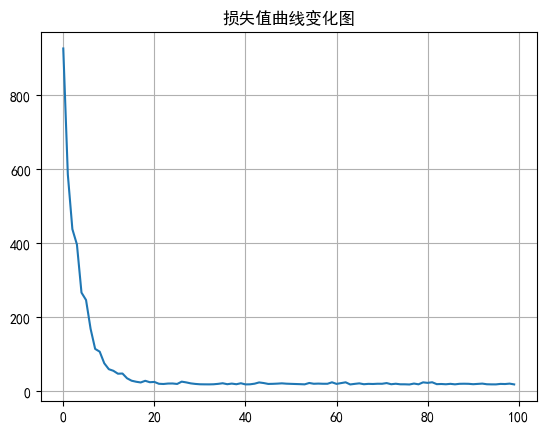

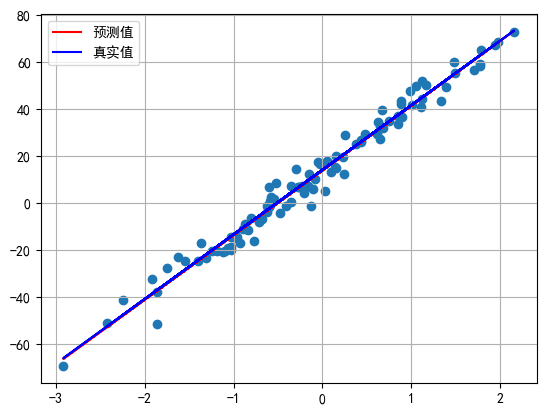

In [66]:
if __name__ == '__main__':
    x, y, coef = create_dataset()
    print(f'x.shape:{x.shape}, y.shape:{y.shape}, coef:{coef}')
    train(x, y, coef)